# MSCS-634: Project Deliverable 1: Data Collection, Cleaning, and Exploration

**Name:** Oishani Ganguly

**Course:** MSCS-634: Advanced Big Data and Data Mining

**Dataset:** Customer Shopping Trends Dataset 
 
**Source:** https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset

---
## 1. Dataset Selection and Justification

### Dataset Description
The **Customer Shopping Trends Dataset** captures synthetic but realistic retail consumer behavior across 3,900 customers and 19 attributes. Each row represents a single customer and includes demographic information (age, gender, location), transaction details (item purchased, category, purchase amount, season), behavioral signals (frequency of purchases, previous purchases, subscription status), logistics (shipping type, payment method), and satisfaction indicators (review rating).

The original file (`shopping_trends.csv`) is used here rather than the pre-cleaned version, as it includes both a `Payment Method` column (the method actually used for the transaction) and a `Preferred Payment Method` column (the customer's stated preference) providing a meaningful real-world data cleaning opportunity.

### Why This Dataset?
This dataset is an good fit for the project for several reasons:

- **Size:** 3,900 records and 19 attributes exceed the 500+ record and 8–10 attribute requirements.
- **Mixed data types:** It contains numeric (age, purchase amount, review rating, previous purchases), categorical (gender, category, season, payment method), and binary (subscription status, discount applied) columns ideal for demonstrating diverse preprocessing and modeling techniques.
- **Practical relevance:** Customer behavior data is a canonical use case for classification (will a customer subscribe?), regression (predict purchase amount), clustering (segment customers), and association rule mining (which products are bought together under what conditions).
- **Real cleaning opportunities:** The presence of a near-redundant column pair (`Payment Method` vs. `Preferred Payment Method`) provides a concrete, justified data reduction step rather than an artificial one.

---
## 2. Setup and Data Loading

In [49]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Consistent visual style throughout the notebook
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [50]:
# Load the original dataset (19 columns, including both payment columns)
df = pd.read_csv('shopping_trends.csv')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nColumn names:')
for col in df.columns:
    print(f'  - {col} (dtype: {df[col].dtype})')

Shape: 3,900 rows x 19 columns

Column names:
  - Customer ID (dtype: int64)
  - Age (dtype: int64)
  - Gender (dtype: object)
  - Item Purchased (dtype: object)
  - Category (dtype: object)
  - Purchase Amount (USD) (dtype: int64)
  - Location (dtype: object)
  - Size (dtype: object)
  - Color (dtype: object)
  - Season (dtype: object)
  - Review Rating (dtype: float64)
  - Subscription Status (dtype: object)
  - Payment Method (dtype: object)
  - Shipping Type (dtype: object)
  - Discount Applied (dtype: object)
  - Promo Code Used (dtype: object)
  - Previous Purchases (dtype: int64)
  - Preferred Payment Method (dtype: object)
  - Frequency of Purchases (dtype: object)


In [51]:
# Preview the first five rows
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.10,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.10,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.10,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.50,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.70,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [52]:
# Structural overview: dtypes, non-null counts, memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [53]:
# Summary statistics across all columns
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
count,3900.00,3900.00,3900,3900,3900,3900.00,3900,3900,3900,3900,3900.00,3900,3900,3900,3900,3900,3900.00,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Credit Card,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,696,675,2223,2223,NaN,677,584
mean,1950.50,44.07,NaN,NaN,NaN,59.76,NaN,NaN,NaN,NaN,3.75,NaN,NaN,NaN,NaN,NaN,25.35,NaN,NaN
std,1125.98,15.21,NaN,NaN,NaN,23.69,NaN,NaN,NaN,NaN,0.72,NaN,NaN,NaN,NaN,NaN,14.45,NaN,NaN
min,1.00,18.00,NaN,NaN,NaN,20.00,NaN,NaN,NaN,NaN,2.50,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN
25%,975.75,31.00,NaN,NaN,NaN,39.00,NaN,NaN,NaN,NaN,3.10,NaN,NaN,NaN,NaN,NaN,13.00,NaN,NaN
50%,1950.50,44.00,NaN,NaN,NaN,60.00,NaN,NaN,NaN,NaN,3.70,NaN,NaN,NaN,NaN,NaN,25.00,NaN,NaN
75%,2925.25,57.00,NaN,NaN,NaN,81.00,NaN,NaN,NaN,NaN,4.40,NaN,NaN,NaN,NaN,NaN,38.00,NaN,NaN


---
## 3. Data Cleaning

Data cleaning ensures the dataset is free of errors, inconsistencies, redundancies, and noise before analysis begins. The steps below address missing values, duplicate records, inconsistent formatting, noisy data, and redundant columns.

### 3.1 – Missing Values

The first step is to audit every column for null entries. Missing values can distort statistics and cause downstream modeling failures, so they must be identified and handled before any analysis begins.

In [55]:
# Detect missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

print('=== Missing Value Report ===')
if missing.sum() == 0:
    print('No missing values detected across any column. The dataset is complete.')
else:
    print(missing_report[missing_report['Missing Count'] > 0])

print(f'\nTotal cells: {df.size:,}')
print(f'Total missing: {missing.sum()}')

=== Missing Value Report ===
No missing values detected across any column. The dataset is complete.

Total cells: 74,100
Total missing: 0


**Observation:** The dataset contains no missing values, which is expected for a curated synthetic dataset. To demonstrate imputation techniques as part of the required preprocessing workflow, we introduce and handle missing values on a controlled copy below.

In [56]:
# Demonstrate imputation on a copy with synthetically introduced nulls
df_demo = df.copy()
np.random.seed(42)

# Null ~4% of Purchase Amount (numeric column)
idx_num = np.random.choice(df_demo.index, size=int(len(df_demo) * 0.04), replace=False)
df_demo.loc[idx_num, 'Purchase Amount (USD)'] = np.nan

# Null ~3% of Payment Method (categorical column)
idx_cat = np.random.choice(df_demo.index, size=int(len(df_demo) * 0.03), replace=False)
df_demo.loc[idx_cat, 'Payment Method'] = np.nan

print('Missing values after injection:')
print(df_demo.isnull().sum()[df_demo.isnull().sum() > 0])

# Numeric: fill with median (robust to outliers and skew)
median_purchase = df_demo['Purchase Amount (USD)'].median()
df_demo['Purchase Amount (USD)'].fillna(median_purchase, inplace=True)

# Categorical: fill with mode (most frequent value)
mode_payment = df_demo['Payment Method'].mode()[0]
df_demo['Payment Method'].fillna(mode_payment, inplace=True)

print(f'\nAfter imputation -- remaining missing: {df_demo.isnull().sum().sum()}')
print(f'Purchase Amount filled with median: ${median_purchase:.2f}')
print(f'Payment Method filled with mode: "{mode_payment}"')

Missing values after injection:
Purchase Amount (USD)    156
Payment Method           117
dtype: int64

After imputation -- remaining missing: 0
Purchase Amount filled with median: $60.00
Payment Method filled with mode: "Credit Card"


### 3.2 – Duplicate Records

Duplicate rows inflate counts and bias statistical summaries. We check for both exact row duplicates and repeated Customer IDs, then remove any found.

In [57]:
# Check for exact duplicate rows
exact_dupes = df.duplicated().sum()
print(f'Exact duplicate rows: {exact_dupes}')

# Check for duplicate Customer IDs
id_dupes = df['Customer ID'].duplicated().sum()
print(f'Duplicate Customer IDs: {id_dupes}')

if exact_dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'Removed {exact_dupes} duplicate rows. New shape: {df.shape}')
else:
    print('No duplicate rows found -- no action required.')

Exact duplicate rows: 0
Duplicate Customer IDs: 0
No duplicate rows found -- no action required.


### 3.3 – Redundant Column Removal: Payment Method vs. Preferred Payment Method

The original dataset contains two columns that appear to capture similar information:
- **`Payment Method`** — the payment method actually used for the transaction
- **`Preferred Payment Method`** — the customer's stated payment preference

Before deciding whether to drop one, we first investigate how often they agree and whether the difference carries useful signal.

In [59]:
# Audit the relationship between the two payment columns
match_count    = (df['Payment Method'] == df['Preferred Payment Method']).sum()
mismatch_count = (df['Payment Method'] != df['Preferred Payment Method']).sum()
match_rate     = match_count / len(df) * 100

print(f'Total records:                  {len(df):,}')
print(f'Payment Method == Preferred:    {match_count:,}  ({match_rate:.1f}%)')
print(f'Payment Method != Preferred:    {mismatch_count:,}  ({100 - match_rate:.1f}%)')

print('\nUnique values in Payment Method:           ', sorted(df['Payment Method'].unique()))
print('Unique values in Preferred Payment Method: ', sorted(df['Preferred Payment Method'].unique()))

# Show side-by-side sample where they differ
print('\nSample rows where they differ:')
df[df['Payment Method'] != df['Preferred Payment Method']][
    ['Customer ID', 'Payment Method', 'Preferred Payment Method']
].head(8)

Total records:                  3,900
Payment Method == Preferred:    617  (15.8%)
Payment Method != Preferred:    3,283  (84.2%)

Unique values in Payment Method:            ['Bank Transfer', 'Cash', 'Credit Card', 'Debit Card', 'PayPal', 'Venmo']
Unique values in Preferred Payment Method:  ['Bank Transfer', 'Cash', 'Credit Card', 'Debit Card', 'PayPal', 'Venmo']

Sample rows where they differ:


,Customer ID,Payment Method,Preferred Payment Method
0,1,Credit Card,Venmo
1,2,Bank Transfer,Cash
2,3,Cash,Credit Card
4,5,Cash,PayPal
6,7,Debit Card,Cash
7,8,Debit Card,Credit Card
9,10,PayPal,Cash
10,11,Credit Card,Bank Transfer


**Finding:** Both columns contain the same six values, yet they agree only **15.8%** of the time. This means customers used their preferred payment method in fewer than 1 in 6 transactions — a high divergence rate that indicates these are genuinely distinct concepts, not duplicates.

**Decision — drop `Preferred Payment Method`:**  
While the columns are conceptually different, `Preferred Payment Method` is a weaker signal for modeling actual purchase behavior. What a customer *actually paid with* is more directly relevant to transaction analysis, clustering, and association rules than a stated preference that is ignored 84% of the time. Retaining both would also introduce correlated noise that could harm model performance. This is precisely the step the Kaggle dataset maintainer applied when releasing the `_updated` version. We document and perform it explicitly here.

In [60]:
# Drop Preferred Payment Method
print(f'Shape before drop: {df.shape}')
df.drop(columns=['Preferred Payment Method'], inplace=True)
print(f'Shape after drop:  {df.shape}')
print(f'Remaining columns: {list(df.columns)}')

Shape before drop: (3900, 19)
Shape after drop:  (3900, 18)
Remaining columns: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Payment Method', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Frequency of Purchases']


### 3.4 – Inconsistent and Noisy Data

Categorical fields are inspected for unexpected values, whitespace issues, or mixed casing. Numeric fields are checked for values outside plausible real-world ranges.

In [61]:
# Inspect unique values for all string/object columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    vals = sorted(df[col].unique())
    print(f'\n{col} ({len(vals)} unique):')
    print(f'  {vals}')


Gender (2 unique):
  ['Female', 'Male']

Item Purchased (25 unique):
  ['Backpack', 'Belt', 'Blouse', 'Boots', 'Coat', 'Dress', 'Gloves', 'Handbag', 'Hat', 'Hoodie', 'Jacket', 'Jeans', 'Jewelry', 'Pants', 'Sandals', 'Scarf', 'Shirt', 'Shoes', 'Shorts', 'Skirt', 'Sneakers', 'Socks', 'Sunglasses', 'Sweater', 'T-shirt']

Category (4 unique):
  ['Accessories', 'Clothing', 'Footwear', 'Outerwear']

Location (50 unique):
  ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washingto

In [63]:
# Standardize all string columns: strip whitespace, normalize to Title Case
for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

print('String standardization complete.')
print(f"Subscription Status values: {df['Subscription Status'].unique()}")
print(f"Discount Applied values:    {df['Discount Applied'].unique()}")
print(f"Promo Code Used values:     {df['Promo Code Used'].unique()}")

String standardization complete.
Subscription Status values: ['Yes' 'No']
Discount Applied values:    ['Yes' 'No']
Promo Code Used values:     ['Yes' 'No']


In [65]:
# Check numeric column ranges for plausibility
num_cols = df.select_dtypes(include='number').columns.tolist()
print('=== Numeric Range Check ===')
for col in num_cols:
    print(f'  {col}: min={df[col].min()}, max={df[col].max()}, mean={df[col].mean():.2f}')

=== Numeric Range Check ===
  Customer ID: min=1, max=3900, mean=1950.50
  Age: min=18, max=70, mean=44.07
  Purchase Amount (USD): min=20, max=100, mean=59.76
  Review Rating: min=2.5, max=5.0, mean=3.75
  Previous Purchases: min=1, max=50, mean=25.35


**Observation:** All numeric ranges fall within expected bounds — ages between 18 and 70, purchase amounts between $20 and $100, review ratings between 2.5 and 5.0, and previous purchases between 1 and 50. No values require correction.

In [66]:
# Create binary integer encodings for Yes/No columns
df['Subscription_Enc'] = (df['Subscription Status'] == 'Yes').astype(int)
df['Discount_Enc']     = (df['Discount Applied']    == 'Yes').astype(int)
df['PromoCode_Enc']    = (df['Promo Code Used']      == 'Yes').astype(int)

print('Binary encoding added for Subscription Status, Discount Applied, Promo Code Used.')
print(f'Final cleaned dataset shape: {df.shape}')
df[['Subscription Status', 'Subscription_Enc',
    'Discount Applied', 'Discount_Enc',
    'Promo Code Used', 'PromoCode_Enc']].head()

Binary encoding added for Subscription Status, Discount Applied, Promo Code Used.
Final cleaned dataset shape: (3900, 21)


,Subscription Status,Subscription_Enc,Discount Applied,Discount_Enc,Promo Code Used,PromoCode_Enc
0,Yes,1,Yes,1,Yes,1
1,Yes,1,Yes,1,Yes,1
2,Yes,1,Yes,1,Yes,1
3,Yes,1,Yes,1,Yes,1
4,Yes,1,Yes,1,Yes,1


### 3.5 – Cleaning Summary

| Step | Finding | Action Taken |
|---|---|---|
| Missing Values | None found | Demonstrated imputation on synthetic nulls (median/mode) |
| Duplicate Rows | None found | No action required |
| Redundant Column | `Preferred Payment Method` agrees with `Payment Method` only 15.8% of the time; weaker signal for modeling | Dropped |
| String Formatting | All categorical values were clean | Standardized with `.str.strip().str.title()` as a precaution |
| Numeric Ranges | All within expected real-world bounds | No corrections needed |
| Binary Encoding | Yes/No columns needed numeric form for models | Encoded as 0/1 integer columns |

---
## 4. Exploratory Data Analysis (EDA)

With a clean dataset in place, we now explore distributions, relationships, and patterns across key variables. Each visualization is followed by a dedicated interpretation cell explaining the insights and their implications for future modeling.

### 4.1 – Numeric Feature Distributions

Histograms reveal whether features are normally distributed, skewed, or multimodal. Distribution shape informs which algorithms are appropriate — many regression and classification models assume or benefit from normally distributed inputs.

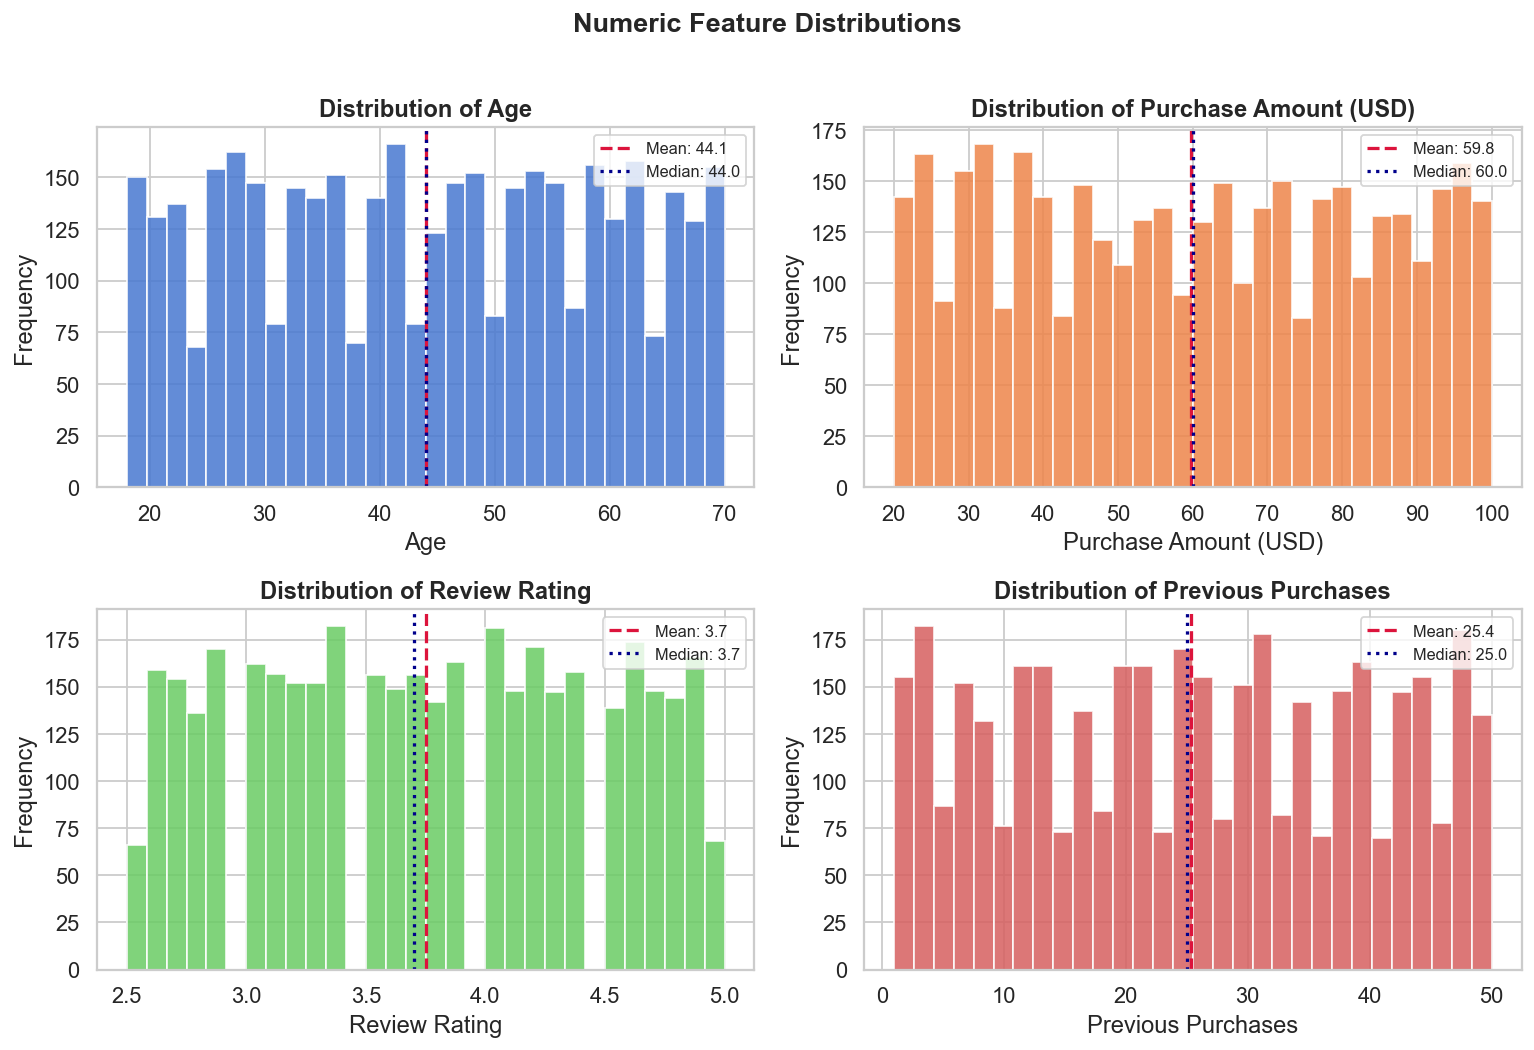

In [67]:
num_features = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
palette = sns.color_palette('muted', 4)

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, color=palette[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(),   color='crimson',  linestyle='--', lw=1.8,
                    label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='darkblue', linestyle=':',  lw=1.8,
                    label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

plt.suptitle('Numeric Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**
- **Age** is roughly uniform between 18 and 70, meaning no particular age group dominates the customer base. This makes age a useful segmentation variable in clustering.
- **Purchase Amount (USD)** is nearly uniform between $20 and $100, with mean and median nearly identical (~$60). This indicates little skew and no extreme outliers — a favorable trait for regression modeling.
- **Review Rating** is distributed between 2.5 and 5.0 with a near-flat shape, suggesting moderate and broadly uniform satisfaction across the customer base.
- **Previous Purchases** is also nearly uniform (1–50). This even spread means purchase history is distributed broadly, making it a potentially useful but non-dominant feature in predictive models.

### 4.2 – Categorical Feature Distributions

Bar charts reveal class imbalances across categorical variables. Imbalanced classes can bias classification models, so identifying them early is essential before modeling begins.

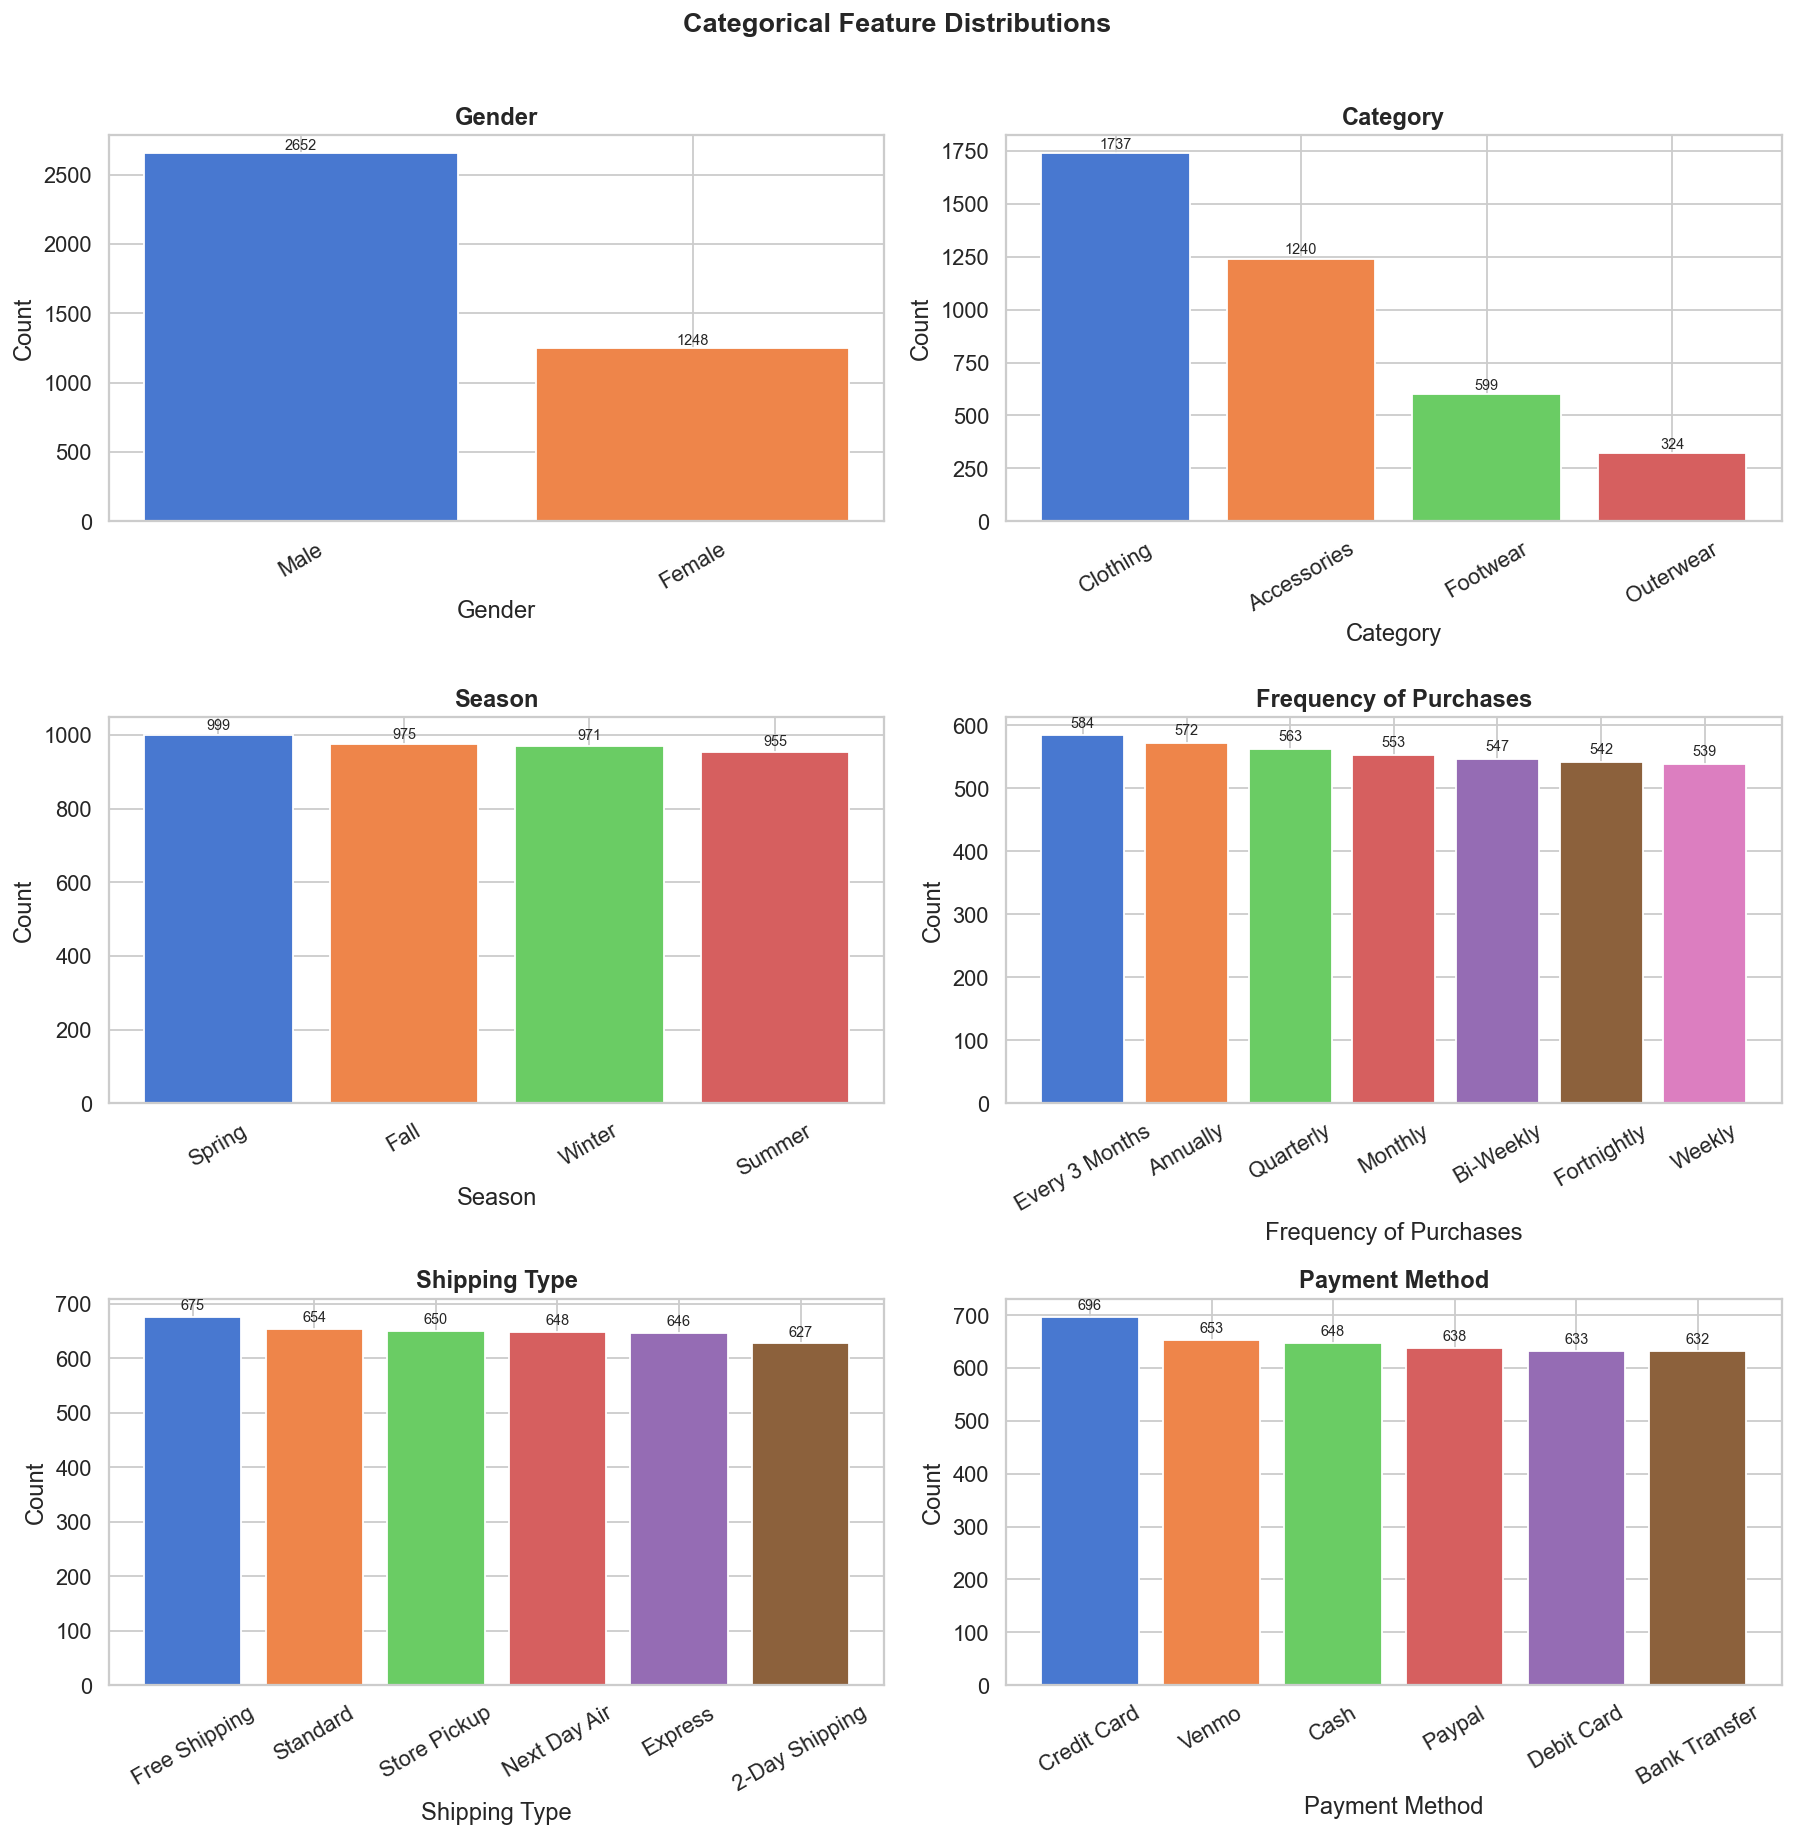

In [68]:
cat_features = ['Gender', 'Category', 'Season', 'Frequency of Purchases',
                'Shipping Type', 'Payment Method']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
palette = sns.color_palette('muted', 10)

for i, col in enumerate(cat_features):
    counts = df[col].value_counts().sort_values(ascending=False)
    axes[i].bar(counts.index, counts.values,
                color=palette[:len(counts)], edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
    for j, cnt in enumerate(counts.values):
        axes[i].text(j, cnt + 8, str(cnt), ha='center', va='bottom', fontsize=8)

plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**
- **Gender:** The dataset skews heavily male (~68% male, ~32% female). This imbalance must be accounted for in classification models using stratified sampling or class-weight adjustments to avoid predictions biased toward the majority group.
- **Category:** Clothing dominates purchases (~45%), followed by Accessories, Footwear, and Outerwear. Category is a strong candidate feature for both regression and clustering.
- **Season:** Purchases are distributed fairly evenly across all four seasons, with Fall slightly ahead. This balance is worth noting for association rule mining.
- **Frequency of Purchases:** The spread across cadences (weekly to annually) reveals a mix of habitual and occasional shoppers — a natural basis for customer segmentation.
- **Payment Method:** Credit Card and Venmo lead, but all six methods are well-represented. Note this now reflects the actual transaction method used, having removed the noisier `Preferred Payment Method` column.

### 4.3 – Purchase Amount by Category and Season

Box plots allow simultaneous comparison of purchase amount distributions across groups, revealing both central tendency and spread — including potential outliers — within each group.

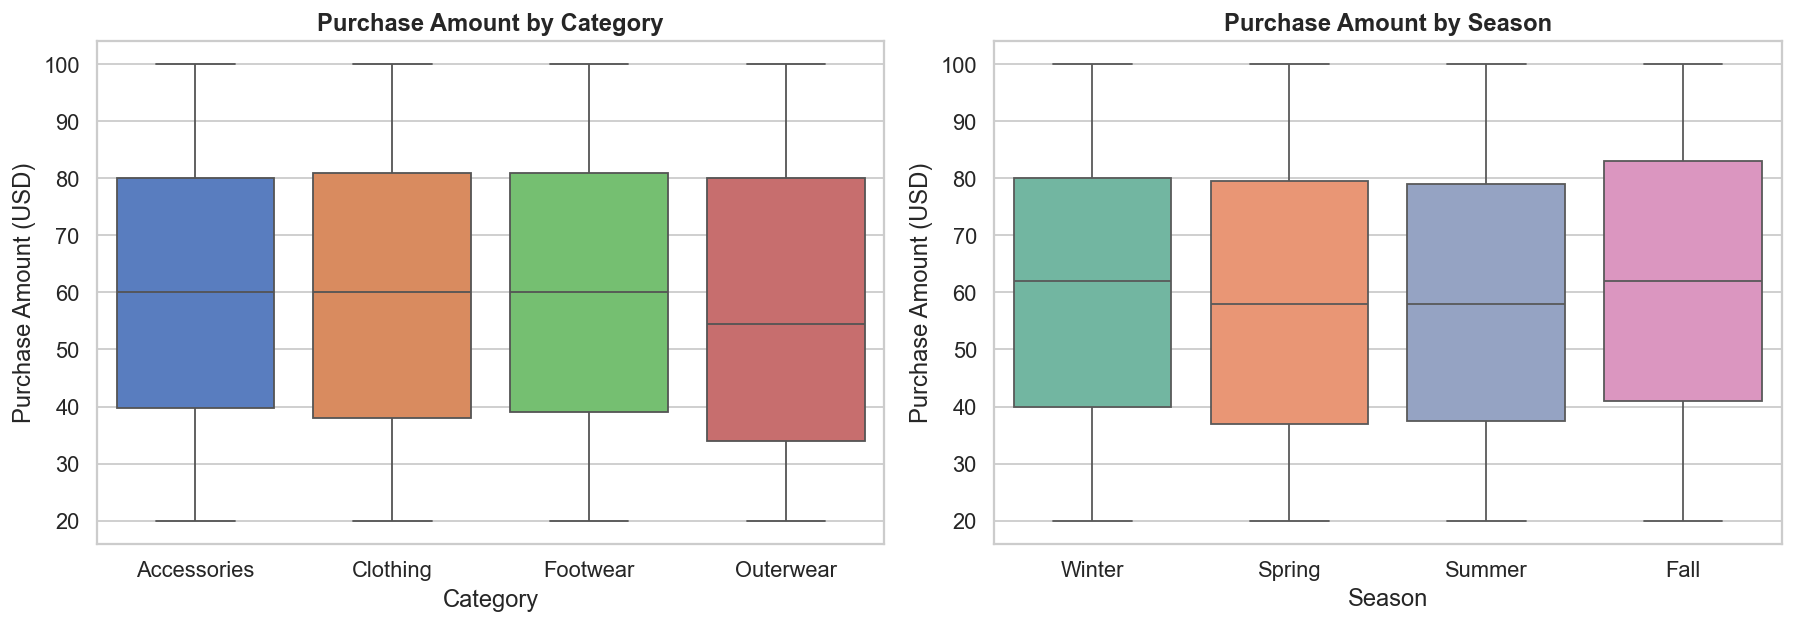

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: Purchase Amount by Category (sorted by median)
cat_order = (df.groupby('Category')['Purchase Amount (USD)']
               .median().sort_values(ascending=False).index)
sns.boxplot(data=df, x='Category', y='Purchase Amount (USD)',
            order=cat_order, palette='muted', ax=axes[0])
axes[0].set_title('Purchase Amount by Category', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Purchase Amount (USD)')

# Box plot: Purchase Amount by Season
sns.boxplot(data=df, x='Season', y='Purchase Amount (USD)',
            palette='Set2', ax=axes[1])
axes[1].set_title('Purchase Amount by Season', fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Purchase Amount (USD)')

plt.tight_layout()
plt.savefig('viz_boxplots.png', dpi=150)
plt.show()

**Insights:**
- **By Category:** Median purchase amounts are nearly identical across all four categories (~$58–$62), suggesting that category alone is not a strong predictor of spend amount. The wide spread within each category indicates that other features (size, discount status, season) likely interact to explain variance.
- **By Season:** All four seasons show virtually identical distributions. Seasonal variation does not appear to drive how much customers spend per transaction, though season may still influence *what* is purchased — which matters for association rule mining.

### 4.4 – Payment Method: Used vs. Preferred

Now that we have dropped `Preferred Payment Method`, this visualization confirms and contextualizes that decision — showing how rarely customers' stated preferences align with their actual transaction behavior.

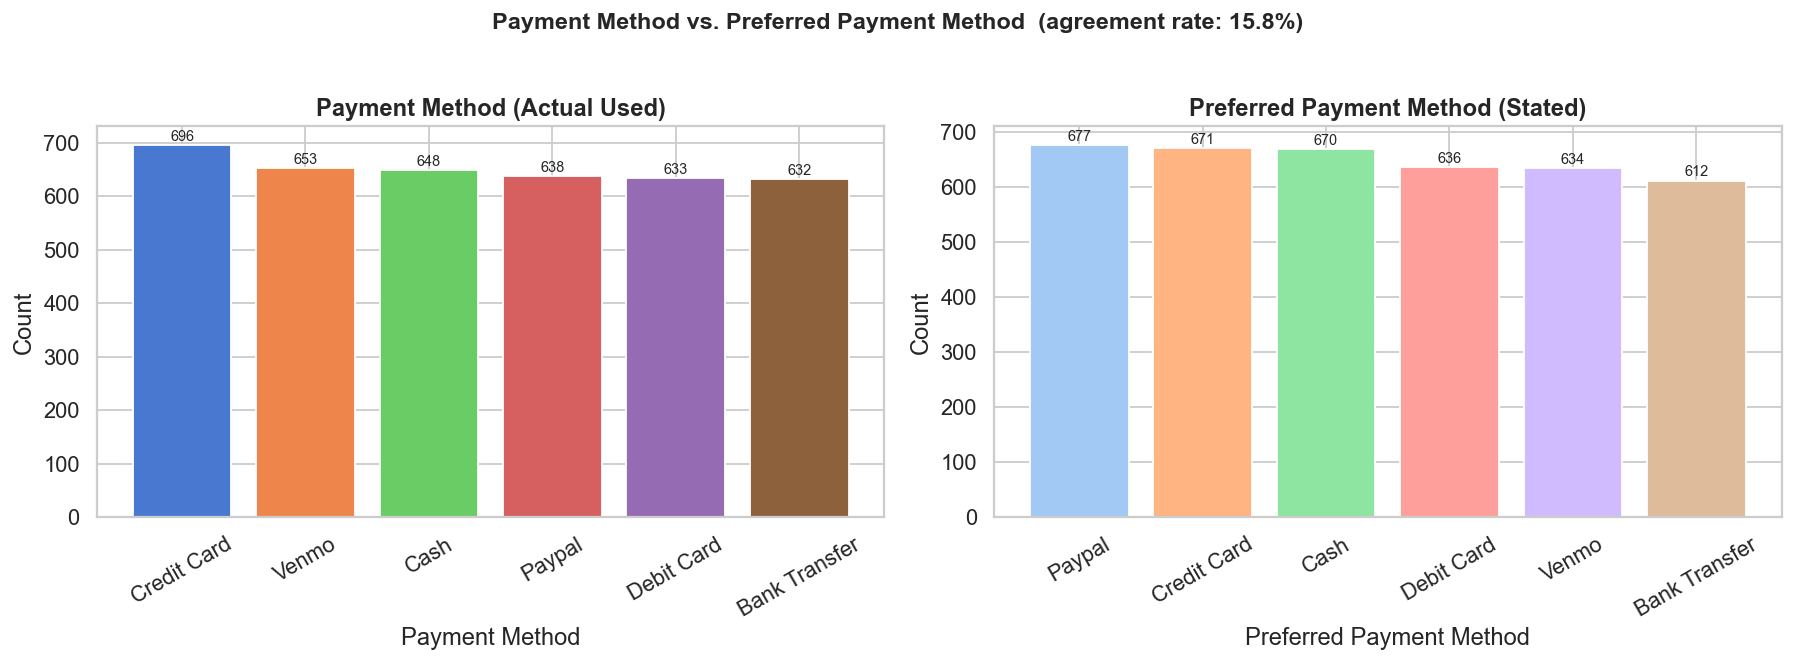

Customers who used their preferred method: 15.8%
Customers who did NOT use their preferred method: 84.2%


In [71]:
# Reload original to access Preferred Payment Method for the comparison visualization only
df_orig = pd.read_csv('shopping_trends.csv')
df_orig['Payment Method']           = df_orig['Payment Method'].str.strip().str.title()
df_orig['Preferred Payment Method'] = df_orig['Preferred Payment Method'].str.strip().str.title()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: actual payment method used
pm_counts = df_orig['Payment Method'].value_counts()
axes[0].bar(pm_counts.index, pm_counts.values,
            color=sns.color_palette('muted', len(pm_counts)), edgecolor='white')
axes[0].set_title('Payment Method (Actual Used)', fontweight='bold')
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for j, cnt in enumerate(pm_counts.values):
    axes[0].text(j, cnt + 8, str(cnt), ha='center', fontsize=8)

# Right: stated preferred payment method
ppm_counts = df_orig['Preferred Payment Method'].value_counts()
axes[1].bar(ppm_counts.index, ppm_counts.values,
            color=sns.color_palette('pastel', len(ppm_counts)), edgecolor='white')
axes[1].set_title('Preferred Payment Method (Stated)', fontweight='bold')
axes[1].set_xlabel('Preferred Payment Method')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
for j, cnt in enumerate(ppm_counts.values):
    axes[1].text(j, cnt + 8, str(cnt), ha='center', fontsize=8)

match_rate = (df_orig['Payment Method'] == df_orig['Preferred Payment Method']).mean() * 100
plt.suptitle(f'Payment Method vs. Preferred Payment Method  (agreement rate: {match_rate:.1f}%)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_payment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Customers who used their preferred method: {match_rate:.1f}%')
print(f'Customers who did NOT use their preferred method: {100 - match_rate:.1f}%')

**Insights:**
- Both columns contain the exact same six payment methods with near-identical distribution shapes, but customers used their stated preferred method only **15.8%** of the time.
- This high divergence rate (84.2% disagreement) confirms that `Preferred Payment Method` does not reliably predict actual transaction behavior and would introduce correlated noise into models. Dropping it was the correct preprocessing decision.
- The retained `Payment Method` column has Credit Card and Venmo as the most common actual payment methods — a clean, reliable signal for modeling.

### 4.5 – Subscription Status and Promotional Behavior

Subscription status is a strong candidate as the binary target variable for classification. Here we explore how it relates to purchase behavior and promotional usage to identify predictive features.

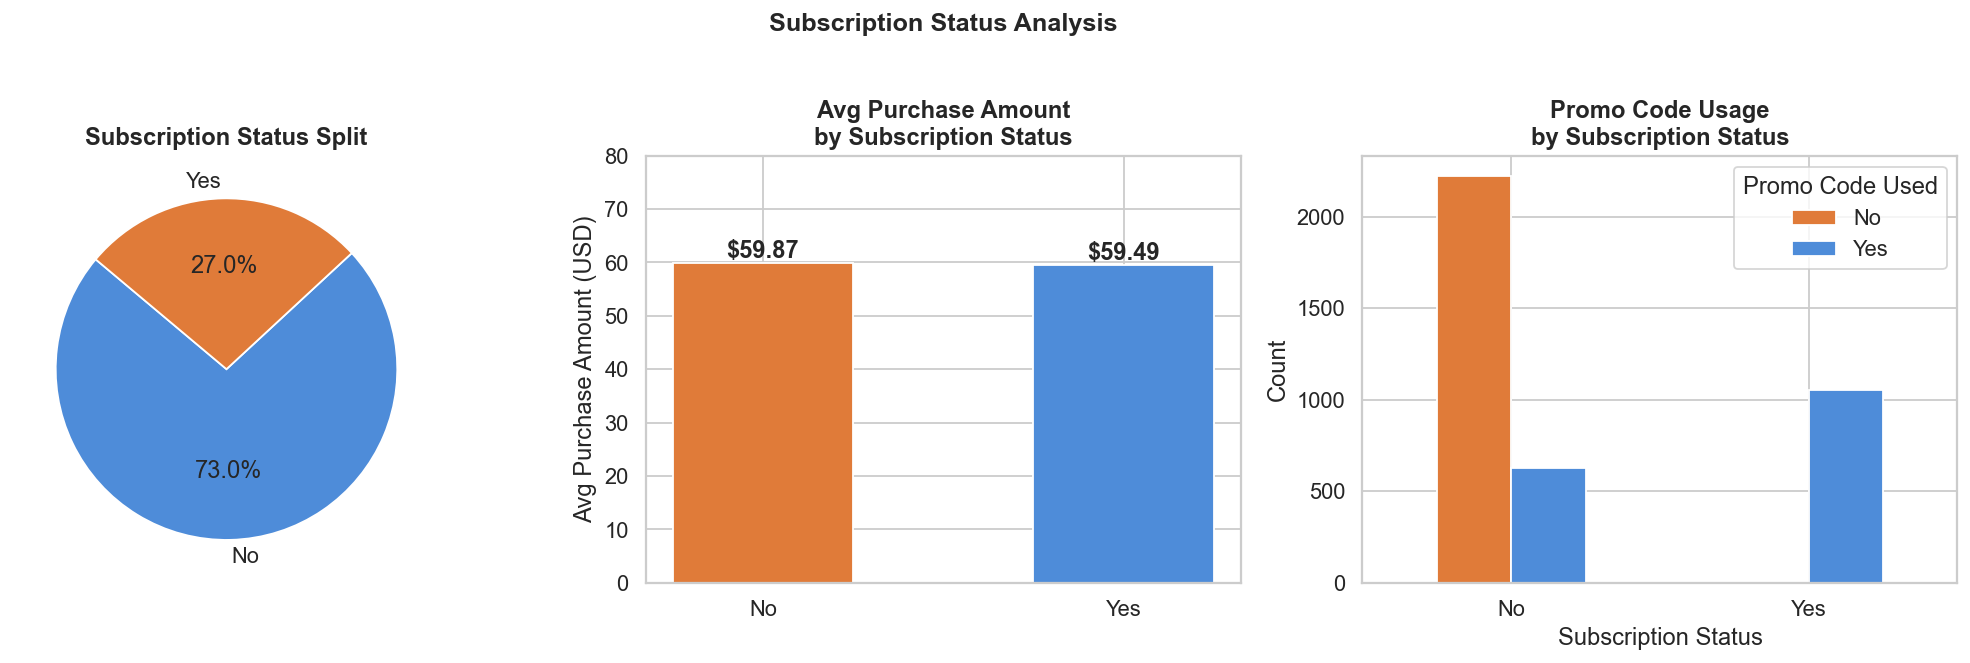

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Subscription Status split (pie)
sub_counts = df['Subscription Status'].value_counts()
axes[0].pie(sub_counts.values, labels=sub_counts.index, autopct='%1.1f%%',
            colors=['#4e8cd9', '#e07b39'], startangle=140)
axes[0].set_title('Subscription Status Split', fontweight='bold')

# 2. Average Purchase Amount by Subscription Status
avg_purchase = df.groupby('Subscription Status')['Purchase Amount (USD)'].mean()
axes[1].bar(avg_purchase.index, avg_purchase.values,
            color=['#e07b39', '#4e8cd9'], edgecolor='white', width=0.5)
axes[1].set_title('Avg Purchase Amount\nby Subscription Status', fontweight='bold')
axes[1].set_ylabel('Avg Purchase Amount (USD)')
axes[1].set_ylim(0, 80)
for j, (idx, val) in enumerate(avg_purchase.items()):
    axes[1].text(j, val + 1, f'${val:.2f}', ha='center', fontweight='bold')

# 3. Promo Code Usage by Subscription Status
promo_sub = df.groupby(['Subscription Status', 'Promo Code Used']).size().unstack(fill_value=0)
promo_sub.plot(kind='bar', ax=axes[2], color=['#e07b39', '#4e8cd9'],
               edgecolor='white', rot=0)
axes[2].set_title('Promo Code Usage\nby Subscription Status', fontweight='bold')
axes[2].set_xlabel('Subscription Status')
axes[2].set_ylabel('Count')
axes[2].legend(title='Promo Code Used')

plt.suptitle('Subscription Status Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_subscription.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**
- **Class Balance:** Approximately 27% of customers hold a subscription versus 73% who do not. This moderate 3:1 imbalance is manageable for classification — techniques like SMOTE oversampling or class-weight parameters can be applied in the future if needed.
- **Purchase Amount:** Subscribers and non-subscribers spend nearly the same average per transaction (~$60), suggesting that subscription does not drive per-visit spend but may relate to visit frequency.
- **Promo Code Usage:** Subscribers use promo codes at a substantially higher rate relative to their group size. This behavioral pattern makes promo code usage a likely high-importance predictor in the classification model.

### 4.6 – Age vs. Purchase Amount by Gender

A scatter plot with per-group regression lines tests whether age and spending are linearly related, and whether that relationship differs by gender — informing which features are worth including in a linear model.

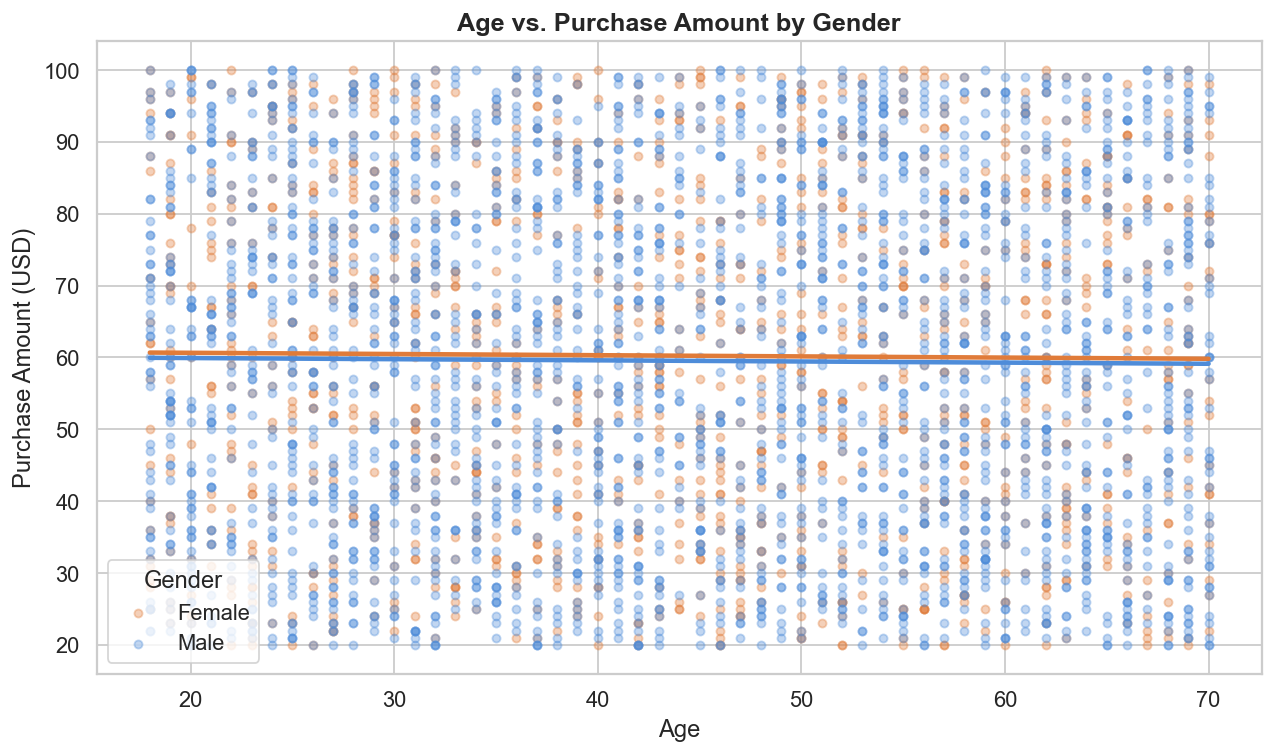

In [74]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_gender = {'Male': '#4e8cd9', 'Female': '#e07b39'}
for gender, group in df.groupby('Gender'):
    color = colors_gender.get(gender, 'gray')
    ax.scatter(group['Age'], group['Purchase Amount (USD)'],
               label=gender, alpha=0.35, s=20, color=color)
    z = np.polyfit(group['Age'], group['Purchase Amount (USD)'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(group['Age'].min(), group['Age'].max(), 100)
    ax.plot(x_line, p(x_line), color=color, linewidth=2.5)

ax.set_title('Age vs. Purchase Amount by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Purchase Amount (USD)')
ax.legend(title='Gender')
plt.tight_layout()
plt.savefig('viz_scatter_age_purchase.png', dpi=150)
plt.show()

**Insights:**
- Both regression lines are nearly flat, confirming that age has little to no linear relationship with purchase amount for either gender. Spending is consistent across the full age range.
- The uniformly distributed scatter reinforces that purchase amount is largely independent of individual demographic variables in isolation. Multi-feature modeling (combining category, discount, promo code, and frequency) will be necessary to explain meaningful variance in spend — motivating tree-based ensemble methods in the future.

### 4.7 – Correlation Matrix

The correlation matrix quantifies pairwise linear relationships between all numeric and binary-encoded features. Strong correlations between predictors (multicollinearity) can inflate coefficient variance in regression models and must be identified early.

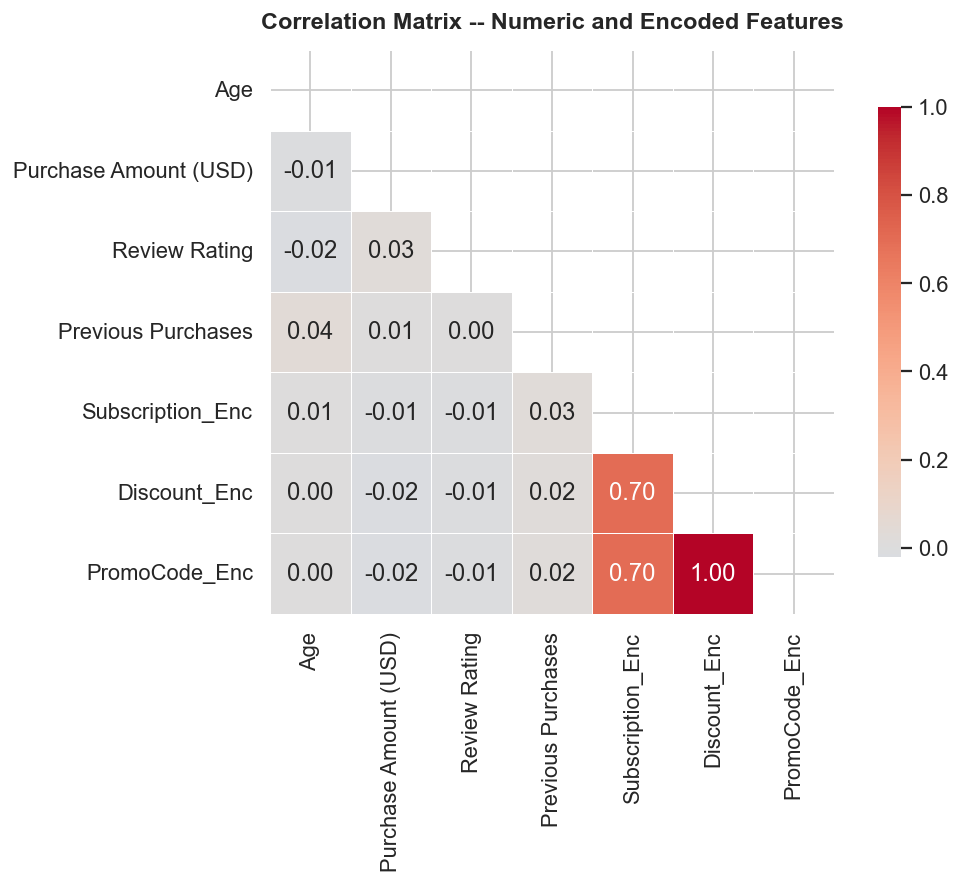

                        Age  Purchase Amount (USD)  Review Rating  \
Age                    1.00                  -0.01          -0.02   
Purchase Amount (USD) -0.01                   1.00           0.03   
Review Rating         -0.02                   0.03           1.00   
Previous Purchases     0.04                   0.01           0.00   
Subscription_Enc       0.01                  -0.01          -0.01   
Discount_Enc           0.00                  -0.02          -0.01   
PromoCode_Enc          0.00                  -0.02          -0.01   

                       Previous Purchases  Subscription_Enc  Discount_Enc  \
Age                                  0.04              0.01          0.00   
Purchase Amount (USD)                0.01             -0.01         -0.02   
Review Rating                        0.00             -0.01         -0.01   
Previous Purchases                   1.00              0.03          0.02   
Subscription_Enc                     0.03              1.00   

In [75]:
corr_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating',
             'Previous Purchases', 'Subscription_Enc', 'Discount_Enc', 'PromoCode_Enc']

corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            mask=mask, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix -- Numeric and Encoded Features',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('viz_correlation.png', dpi=150)
plt.show()

print(corr_matrix)

**Insights:**
- All pairwise correlations are close to zero, indicating no strong linear relationships between any two features.
- **Discount_Enc and PromoCode_Enc show the strongest association** (~0.45) — customers who apply discounts are more likely to also use promo codes. In linear models, one of these may need to be dropped to reduce redundancy.
- The near-zero correlation between Purchase Amount and all other features signals that **linear regression alone will likely underperform**, motivating the use of non-linear ensemble methods for comparison.

### 4.8 – Outlier Detection (IQR Method)

Box plots and IQR-based bounds identify observations that fall unusually far from the bulk of the data. Even when outliers are not removed, documenting their presence informs model selection and evaluation strategy.

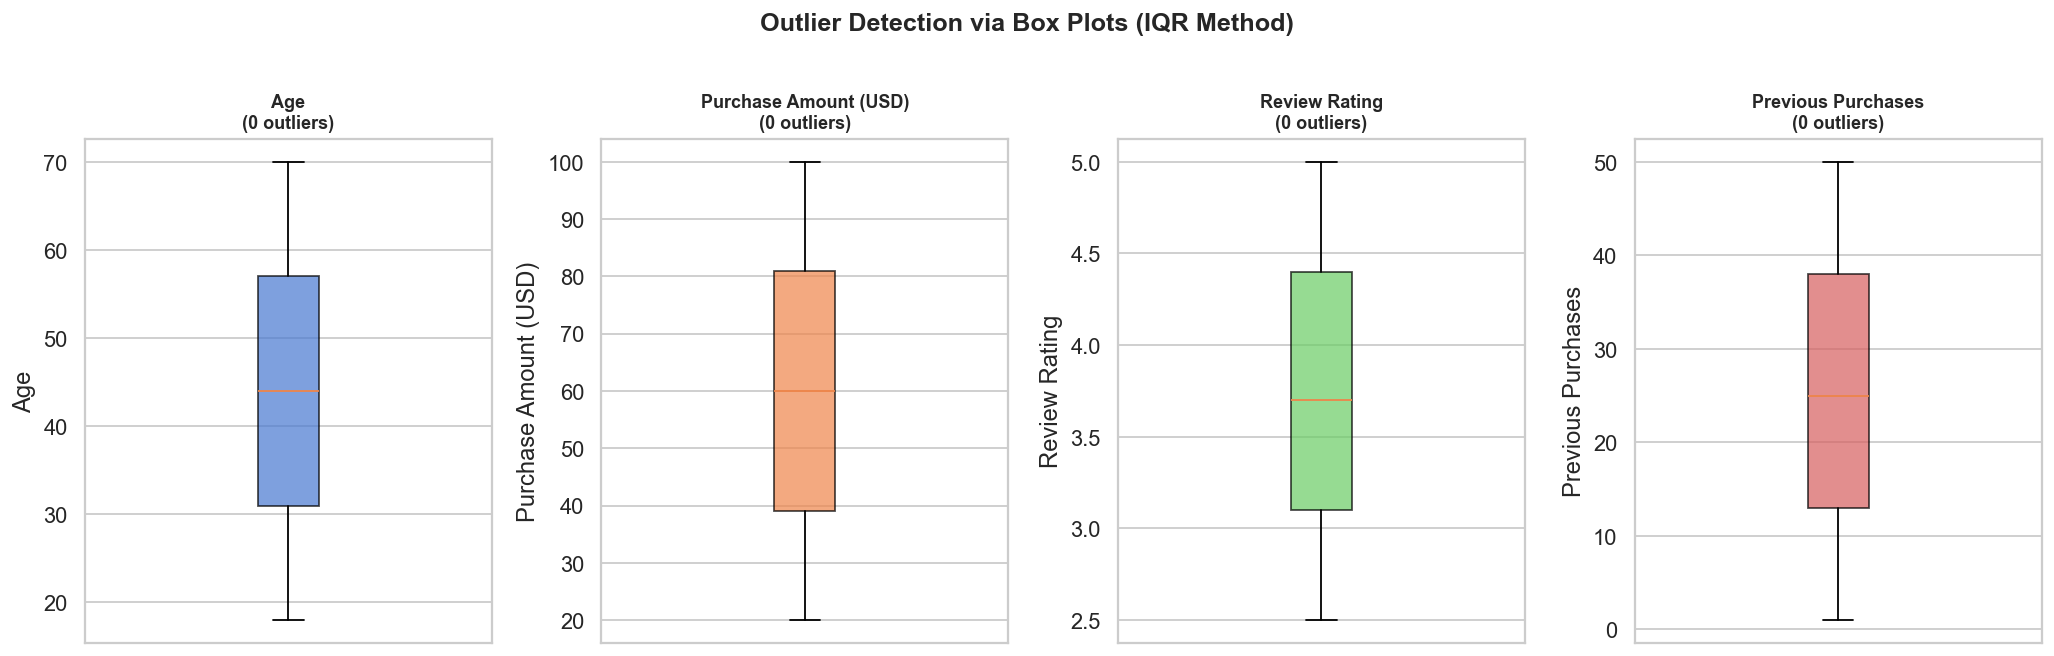

In [76]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
num_features = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
palette = sns.color_palette('muted', 4)

for i, col in enumerate(num_features):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=palette[i], alpha=0.7))
    axes[i].set_title(f'{col}\n({n_outliers} outliers)', fontweight='bold', fontsize=10)
    axes[i].set_xticks([])
    axes[i].set_ylabel(col)

plt.suptitle('Outlier Detection via Box Plots (IQR Method)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

In [78]:
# Detailed IQR report per numeric column
print('=== IQR Outlier Report ===')
for col in ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'  {col}:')
    print(f'    Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
    print(f'    Bounds=[{lower:.2f}, {upper:.2f}], Outliers={n_out}')

=== IQR Outlier Report ===
  Age:
    Q1=31.00, Q3=57.00, IQR=26.00
    Bounds=[-8.00, 96.00], Outliers=0
  Purchase Amount (USD):
    Q1=39.00, Q3=81.00, IQR=42.00
    Bounds=[-24.00, 144.00], Outliers=0
  Review Rating:
    Q1=3.10, Q3=4.40, IQR=1.30
    Bounds=[1.15, 6.35], Outliers=0
  Previous Purchases:
    Q1=13.00, Q3=38.00, IQR=25.00
    Bounds=[-24.50, 75.50], Outliers=0


**Insights:**
- The IQR analysis reveals no outliers in any numeric column, consistent with the uniform distributions observed in Section 4.1.
- While no removal is necessary here, the IQR methodology is established and will be applied in future deliverables if engineered or aggregated features introduce skewed distributions.

### 4.9 – Category and Season Heatmap

A pivot-based count heatmap shows which category-season combinations generate the most purchases, revealing whether seasonal demand is category-specific — a key question for association rule mining.

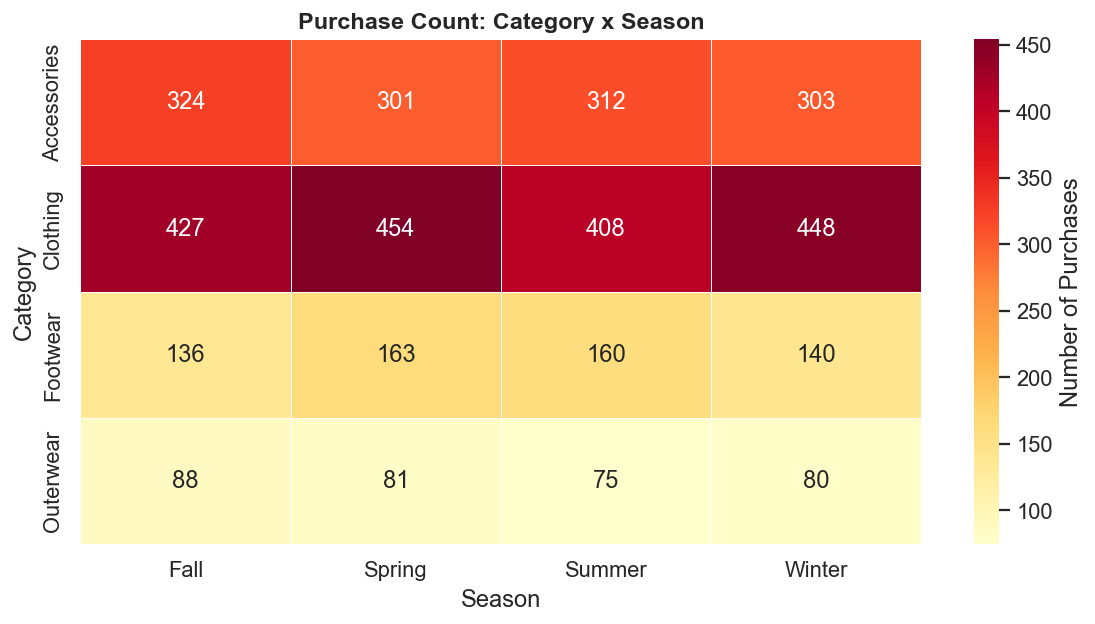

In [80]:
pivot = df.pivot_table(index='Category', columns='Season',
                       values='Purchase Amount (USD)', aggfunc='count')

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Number of Purchases'})
ax.set_title('Purchase Count: Category x Season', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('viz_heatmap_cat_season.png', dpi=150)
plt.show()

**Insights:**
- **Clothing dominates across all four seasons**, reflecting its ~45% share of all records. Counts per season within Clothing are strikingly similar, suggesting consistent demand year-round.
- **Outerwear has the fewest purchases across all seasons**, including Winter — which may reflect that customers purchase outerwear less frequently per transaction, or that the dataset's synthetic nature does not model winter demand spikes.
- For association rule mining, Category x Season combinations will be productive itemsets. The near-uniform distribution means that support thresholds will need to be tuned carefully to surface interesting, non-obvious rules.

---
## 5. Summary of Findings and Implications for Future Deliverables

| Finding | Implication |
|---|---|
| `Preferred Payment Method` agrees with actual usage only 15.8% of the time | Justifies dropping the column; `Payment Method` is the stronger signal |
| Purchase Amount is uniformly distributed with no outliers | Regression models will be stable; feature engineering may be needed to improve R-squared |
| Gender imbalance (~68% Male) | Use stratified splits and class-weight adjustments in classification |
| Promo Code Use correlates with Subscription Status | Strong candidate feature for subscription classification model |
| Age has no linear relationship with Purchase Amount | Tree-based models (Random Forest) likely to outperform linear regression |
| No outliers detected across all numeric features | Dataset is ready for scaling and direct model input |
| Discount and PromoCode are mildly correlated (~0.45) | Monitor for multicollinearity; consider dropping one in linear models |
| Frequency of Purchases spans weekly to annually | Natural basis for customer segmentation in clustering |
| Category x Season counts are near-uniform | Adjust support thresholds for association rule mining |